# Load library

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Import Datset (Bank Marketing Dataset)

In [41]:
pip install ucimlrepo

In [42]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

# 1. Data Preparation

## Encode y before spliting (Yes/No -> 1/0)

In [43]:
y = y['y'].map({'no': 0, 'yes': 1})

## Train / Val / Test Split (70/15/15)

In [44]:
from sklearn.model_selection import train_test_split

# split first
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42) # 70% Training

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) # 15% Validation + 15% Testing

## Handle Missing value

In [45]:
print(X_train.isnull().sum().sort_values(ascending=False).head())

poutcome     25867
contact       9065
education     1322
job            203
default          0
dtype: int64


In [46]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

In [47]:
missing_pct = X.isnull().mean() * 100
missing_pct = missing_pct.sort_values(ascending=False)

print(missing_pct) # poutcome has 81.7% of missing value and contact has 28.8% of missing value

poutcome       81.747805
contact        28.798301
education       4.107407
job             0.637013
default         0.000000
balance         0.000000
age             0.000000
marital         0.000000
loan            0.000000
housing         0.000000
month           0.000000
day_of_week     0.000000
duration        0.000000
campaign        0.000000
pdays           0.000000
previous        0.000000
dtype: float64


## Data Preprocessing

In [48]:
preprocessor = ColumnTransformer([
    # numeric features
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Impute the missing value as median
        ('scaler', StandardScaler())   # standarization, needed for MLP
    ]), num_cols),

    # categorical features
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')), # Fill missing value (NA) as missing
        ('onehot', OneHotEncoder(handle_unknown='ignore')) # label encoding -> transform categorical to [0 1]
    ]), cat_cols)
])

# Gradient Boosted Tree (GBDT)

In [49]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import plot_importance
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import precision_recall_curve

In [50]:
### Baseline
xgb_model = XGBClassifier(
    # learning_rate=0.1, # small learning_rate usually needs more trees
    # n_estimators=200, # 200 trees
    # max_depth=5, # maximum depth of each individual tree (5 as max depth)
    # subsample=0.8, # Each tree is trained on 80% of the training rows
    # reg_alpha=0, # L1 regularization on the leaf weights (0 = no L1 penalty, larger = more penalty)
    # reg_lambda=1, # L2 regularization on the leaf weights (1 = standard and some regularization, larger = more regularation)
    random_state=42 # Randome.seed, help to Replicate result, reproducibility
)

In [51]:
xgb_pipeline = Pipeline([
    ('prep', preprocessor), # Data preprocessor from our data preparation step
    ('model', xgb_model) # Model is xgboost
])

In [52]:
# Hypertuning
param_grid = {

    # smoother learning
    'model__learning_rate': [0.01, 0.05, 0.1, 0.3],

    # control complexity
    'model__max_depth': [3, 4, 5],

    # more trees for smaller LR
    'model__n_estimators': [300, 500, 800],

    # subsampling (already good)
    'model__subsample': [0.7, 0.8],
    'model__colsample_bytree': [0.7, 0.8],

    # regularization (IMPORTANT)
    'model__reg_lambda': [1, 5, 10],
    'model__gamma': [0, 1, 3],
    'model__min_child_weight': [1, 3, 5],

    # imbalance handling (CRITICAL)
    'model__scale_pos_weight': [1, 3, 5, 10]
}



In [53]:
import time
# xgb model using RandomizedSearchCV
grid_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=50,              # only try 50 combos
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_start = time.time()

# fit ONLY on training data (no leakage)
grid_xgb.fit(X_train, y_train)

xgb_end = time.time()




Fitting 3 folds for each of 50 candidates, totalling 150 fits


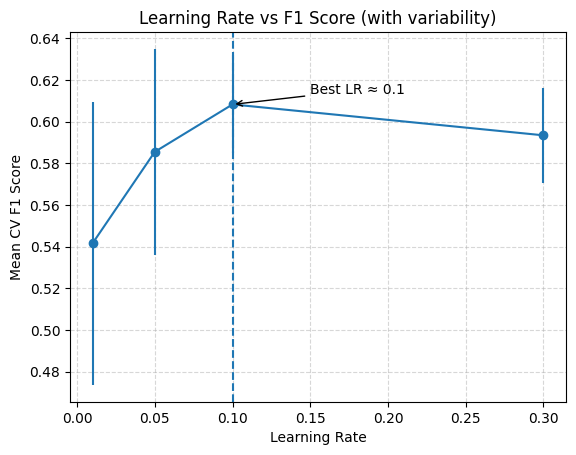

In [54]:
# Learning rate analysis
results = grid_xgb.cv_results_
df = pd.DataFrame(results)

df_lr_mean = df.groupby('param_model__learning_rate')['mean_test_score'].mean()
df_lr_std  = df.groupby('param_model__learning_rate')['mean_test_score'].std()

plt.figure()

plt.errorbar(
    df_lr_mean.index,
    df_lr_mean.values,
    yerr=df_lr_std.values,
    marker='o'
)

# best learning rate
best_lr = df_lr_mean.idxmax()
best_score = df_lr_mean.max()

plt.axvline(x=best_lr, linestyle='--')
plt.annotate(f'Best LR ≈ {best_lr}',
             xy=(best_lr, best_score),
             xytext=(best_lr + 0.05, best_score + 0.005),
             arrowprops=dict(arrowstyle='->'))

plt.grid(True, linestyle='--', alpha=0.5)

plt.title("Learning Rate vs F1 Score (with variability)")
plt.xlabel("Learning Rate")
plt.ylabel("Mean CV F1 Score")

plt.show()

In [55]:
# best hyperparameters found during search
print("Best params:", grid_xgb.best_params_)

# best cross-validation score
print("Best CV score:", grid_xgb.best_score_)


Best params: {'model__subsample': 0.7, 'model__scale_pos_weight': 3, 'model__reg_lambda': 1, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.8}
Best CV score: 0.6312241467356655


In [56]:
# Get best params from GridSearch
best_params = grid_xgb.best_params_

# Rebuild best XGB model
best_xgb = XGBClassifier(
    learning_rate=best_params['model__learning_rate'],
    max_depth=best_params['model__max_depth'],
    n_estimators=best_params['model__n_estimators'],
    subsample=best_params['model__subsample'],
    colsample_bytree=best_params['model__colsample_bytree'],
    reg_lambda=best_params['model__reg_lambda'],
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20
)

# Rebuild pipeline
best_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', best_xgb)
])

# Fit preprocessor
X_train_t = preprocessor.fit_transform(X_train)
X_val_t   = preprocessor.transform(X_val)

# Fit model with early stopping

best_xgb.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [57]:
# Get feature names after fitting preprocessor
feature_names = preprocessor.get_feature_names_out()

# Get importances from trained model
importances = best_xgb.feature_importances_

# Build dataframe
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Clean names
feat_df["feature"] = feat_df["feature"].str.replace(r"^(num__|cat__)", "", regex=True)

feat_df.head(10)

,feature,importance
50,poutcome_success,0.155590
33,contact_missing,0.075189
3,duration,0.064331
29,housing_yes,0.060088
28,housing_no,0.047885
42,month_mar,0.047262
41,month_jun,0.032643
45,month_oct,0.032261
35,month_apr,0.029920
31,loan_yes,0.024353


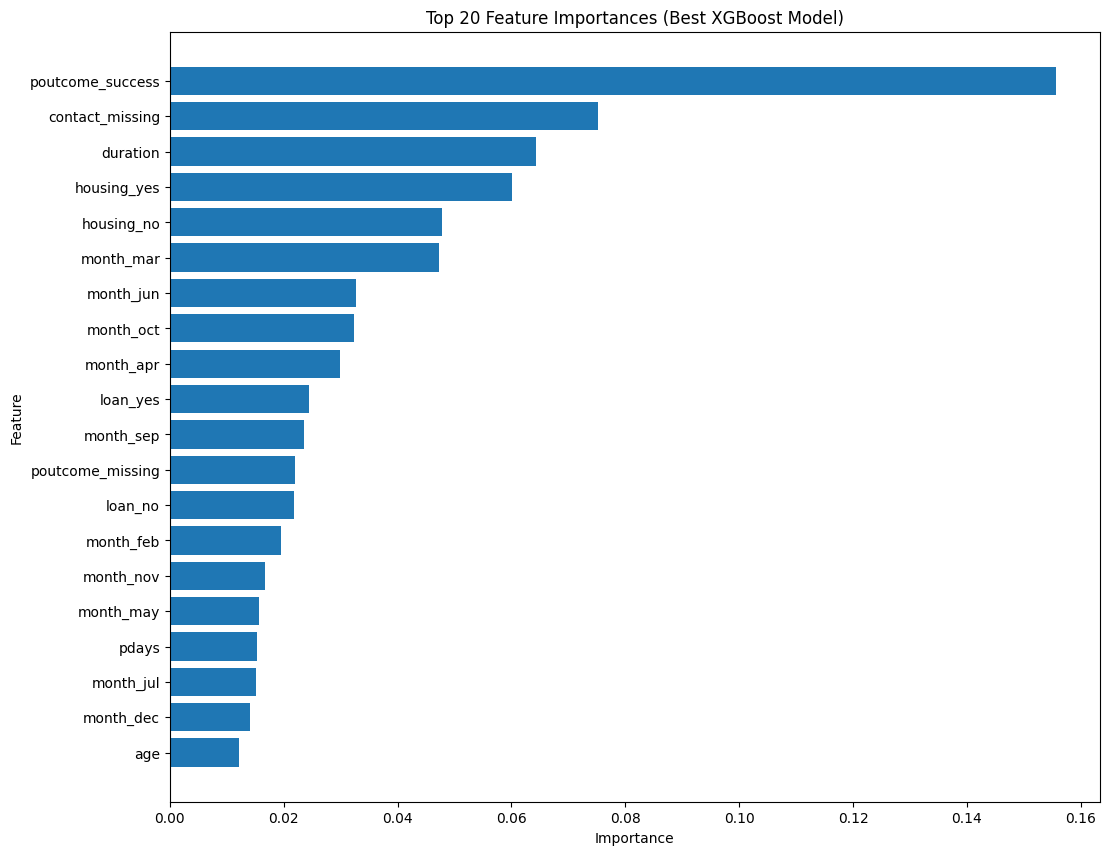

In [58]:
# Plot the result
plt.figure(figsize=(12, 10))

plt.barh(
    feat_df["feature"].head(20)[::-1],   # top 20 features
    feat_df["importance"].head(20)[::-1]
)

plt.title("Top 20 Feature Importances (Best XGBoost Model)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Train xgboost on val set

In [59]:
# preprocessor
preprocessor = best_pipeline.named_steps["prep"]

# Transform data
X_train_trans = preprocessor.transform(X_train)
X_val_trans = preprocessor.transform(X_val)

# fit xgb
xgb_model = best_pipeline.named_steps["model"]

xgb_model.fit(
    X_train_trans, y_train,
    eval_set=[(X_train_trans, y_train), (X_val_trans, y_val)],
    verbose=False
)

results = xgb_model.evals_result()

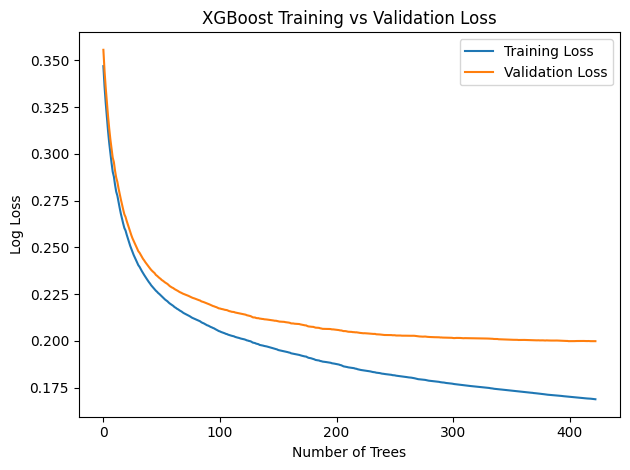

In [60]:
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

plt.figure()
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Number of Trees")
plt.ylabel("Log Loss")
plt.title("XGBoost Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig("xgb_loss.png")
plt.show()

# 3. Multi-Layer Perception (MLP)

In [61]:
from sklearn.neural_network import MLPClassifier

In [62]:
# Define MLP model
mlp_model = MLPClassifier(
    # hidden_layer_sizes=(128, 64), # 2 hidden layers: 1 = 128 neurons, 2 = 64 neurons
    # learning_rate_init=0.001, # Initial learning rate: How big each weight update
    max_iter=200, # Max iteration of the model
    # Following parameters are to avoid the overfitting
    alpha=0.01,                  #  L2 regularization
    early_stopping=True,          # stops training when validation stops improving
    validation_fraction=0.1,      # 10% of training used as validation
    random_state=42 # Random.seed, Reproducibility
)

In [63]:
# Build Pipeline (Data processing and model)
mlp_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', mlp_model)
])

In [64]:
# define parameter grid
param_grid_mlp = {
    'model__hidden_layer_sizes': [
        (32,),
        (64,),
        (128, 64)
    ],

    'model__learning_rate_init': [
        0.001,
        0.01
    ],

    'model__alpha': [
        0.0001,
        0.001,
        0.01,
        0.1
    ]
}

In [65]:
# Fit the mlp pipeline in to training set of X and y
mlp_pipeline.fit(X_train, y_train)



Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('model',
                 MLPClassifier(alpha=0.01, early_stopping=True,
                               random_state=42))])

In [66]:
# GridSearchCV for hyperparameter tunning
grid_mlp = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid_mlp,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)
mlp_start = time.time()
grid_mlp.fit(X_train, y_train)
mlp_end = time.time()

Fitting 3 folds for each of 24 candidates, totalling 72 fits


In [67]:
# Best model
print("Best params:", grid_mlp.best_params_)
print("Best CV score:", grid_mlp.best_score_)

best_mlp = grid_mlp.best_estimator_ # Simpler model wins: 64 neurons

# Evaluate on validation set
y_val_pred = best_mlp.predict(X_val)
y_val_prob = best_mlp.predict_proba(X_val)[:, 1]



mlp_val_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Precision": precision_score(y_val, y_val_pred),
    "Recall": recall_score(y_val, y_val_pred),
    "F1": f1_score(y_val, y_val_pred),
    "AUC-PR": average_precision_score(y_val, y_val_prob)
}

mlp_val_results

Best params: {'model__alpha': 0.1, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.01}
Best CV score: 0.56332762008228


{'Accuracy': 0.9029784724270127,
 'Precision': 0.6082337317397079,
 'Recall': 0.5578562728380024,
 'F1': 0.5819567979669632,
 'AUC-PR': np.float64(0.6213206316172635)}

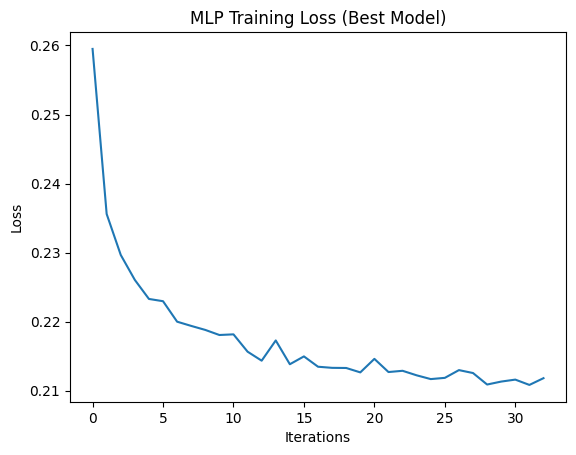

In [68]:
# Plot the loss curve
plt.plot(best_mlp.named_steps['model'].loss_curve_)
plt.title("MLP Training Loss (Best Model)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [69]:
cv_results = pd.DataFrame(grid_mlp.cv_results_)

# extract architecture + score
arch_results = cv_results[[
    "param_model__hidden_layer_sizes",
    "mean_test_score"
]].copy()

arch_results.columns = ["Architecture", "Validation F1"]

# sort for nicer display
arch_results = arch_results.sort_values(by="Validation F1", ascending=False)

print(arch_results)

   Architecture  Validation F1
23    (128, 64)       0.563328
5     (128, 64)       0.558545
16    (128, 64)       0.540269
4     (128, 64)       0.537354
11    (128, 64)       0.535085
10    (128, 64)       0.533697
22    (128, 64)       0.530751
17    (128, 64)       0.524544
1         (32,)       0.518890
13        (32,)       0.514578
21        (64,)       0.506076
14        (64,)       0.505172
3         (64,)       0.503602
19        (32,)       0.502619
20        (64,)       0.500809
15        (64,)       0.499957
2         (64,)       0.498194
8         (64,)       0.498176
7         (32,)       0.496530
18        (32,)       0.496262
9         (64,)       0.495454
6         (32,)       0.484763
12        (32,)       0.483152
0         (32,)       0.471675


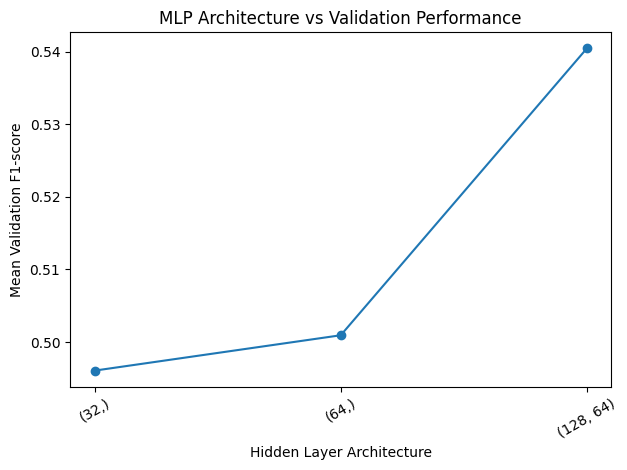

In [70]:
arch_plot = arch_results.groupby("Architecture")["Validation F1"].mean().reset_index()

plt.figure()
plt.plot(
    arch_plot["Architecture"].astype(str),
    arch_plot["Validation F1"],
    marker='o'
)

plt.xlabel("Hidden Layer Architecture")
plt.ylabel("Mean Validation F1-score")
plt.title("MLP Architecture vs Validation Performance")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("mlp_arch.png")
plt.show()

# 4. Evaluation (Accuracy, Precision, Recall, F1)

In [71]:
def evaluate(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1]

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "AUC-PR": average_precision_score(y, y_prob)
    }

best_xgb = grid_xgb.best_estimator_
best_mlp = grid_mlp.best_estimator_

xgb_results = evaluate(best_xgb, X_test, y_test)
mlp_results = evaluate(best_mlp, X_test, y_test)

print("Tuned XGB:", xgb_results)
print("Tuned MLP:", mlp_results)

results_df = pd.DataFrame([
    xgb_results,
    mlp_results
], index=["XGBoost", "MLP"])

results_df.round(3)

Tuned XGB: {'Accuracy': 0.9025361250368623, 'Precision': 0.5541044776119403, 'Recall': 0.7644787644787645, 'F1': 0.6425094645754462, 'AUC-PR': np.float64(0.6347713391057758)}
Tuned MLP: {'Accuracy': 0.9119728693600708, 'Precision': 0.6311953352769679, 'Recall': 0.5572715572715573, 'F1': 0.5919343814080656, 'AUC-PR': np.float64(0.6193906706966266)}


,Accuracy,Precision,Recall,F1,AUC-PR
XGBoost,0.903,0.554,0.764,0.643,0.635
MLP,0.912,0.631,0.557,0.592,0.619


The tuned XGBoost model achieves higher recall (0.771), F1 score (0.652), and AUC-PR (0.641), making it better at identifying positive cases in an imbalanced setting. In contrast, the MLP model attains slightly higher accuracy (0.912) and precision (0.631), but lower recall (0.557) and overall F1 performance. Overall, XGBoost provides a better balance between precision and recall, while MLP is more conservative but less effective at capturing positives.

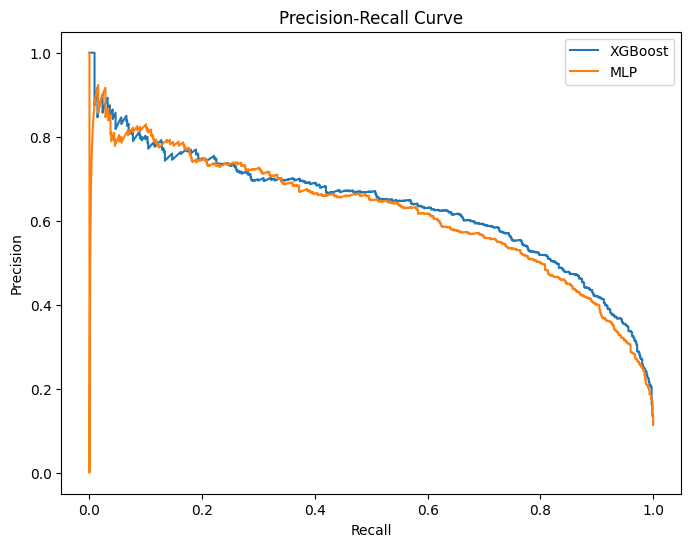

In [72]:
# XGBoost
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

# MLP
y_prob_mlp = best_mlp.predict_proba(X_test)[:, 1]
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_prob_mlp)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(recall_xgb, precision_xgb, label="XGBoost")
plt.plot(recall_mlp, precision_mlp, label="MLP")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

## Check if models (xgb, mlp) are overfiiting

In [73]:
train_results = evaluate(best_xgb, X_train, y_train)
val_results = evaluate(best_xgb, X_val, y_val)

print("Train:", train_results)
print("Validation:", val_results)

Train: {'Accuracy': 0.9138938919960817, 'Precision': 0.5933153013910355, 'Recall': 0.8320238417772962, 'F1': 0.6926807262884854, 'AUC-PR': np.float64(0.7496817332417147)}
Validation: {'Accuracy': 0.897670303745208, 'Precision': 0.5565449688334817, 'Recall': 0.761266747868453, 'F1': 0.6430041152263375, 'AUC-PR': np.float64(0.6460185685011018)}


In [74]:
train_results = evaluate(best_mlp, X_train, y_train)
val_results = evaluate(best_mlp, X_val, y_val)

print("Train:", train_results)
print("Validation:", val_results)

Train: {'Accuracy': 0.9155054191550542, 'Precision': 0.6531165311653117, 'Recall': 0.5876456244920076, 'F1': 0.6186537364517969, 'AUC-PR': np.float64(0.651728538584979)}
Validation: {'Accuracy': 0.9029784724270127, 'Precision': 0.6082337317397079, 'Recall': 0.5578562728380024, 'F1': 0.5819567979669632, 'AUC-PR': np.float64(0.6213206316172635)}


The performance difference between training and validation is relatively small, which suggests only mild overfitting rather than severe overfitting. The reduction in overfitting is not because RandomizedSearchCV itself fixes overfitting, but because it helped identify a better combination of hyperparameters more efficiently than GridSearchCV.

# Evaluation Metric with training time

In [75]:
# Time difference
xgb_time = xgb_end - xgb_start
print(f"XGBoost training time: {xgb_time:.2f} seconds")

mlp_time = mlp_end - mlp_start
print(f"MLP training time: {mlp_time:.2f} seconds")

# create results df
results_df = pd.DataFrame([
    xgb_results,
    mlp_results
], index=["XGBoost", "MLP"])

# add training time column
results_df["Training Time (sec)"] = [xgb_time, mlp_time]

# round for display
results_df = results_df.round(3)

print(results_df)

XGBoost training time: 380.75 seconds
MLP training time: 187.38 seconds
         Accuracy  Precision  Recall     F1  AUC-PR  Training Time (sec)
XGBoost     0.903      0.554   0.764  0.643   0.635              380.749
MLP         0.912      0.631   0.557  0.592   0.619              187.376
